# Supervised Fine-Tuning (SFT) Lab: Intent Classification

Welcome to the **Supervised Fine-Tuning Workshop**! In this hands-on lab, you will learn how to take a pre-trained large language model (LLM) and fine-tune it for a specific task — **intent classification** for a doctor appointment booking system.

### What You'll Learn
- How **tokenizers** convert text into numbers that models understand
- How to run **inference** (predictions) with a pre-trained LLM
- How to **prepare and format data** for fine-tuning
- How to fine-tune a model using **LoRA** (Low-Rank Adaptation) — a memory-efficient technique
- How to **evaluate** your fine-tuned model against the base model

### The Task
We have a dataset of user messages sent to a doctor appointment booking chatbot. Each message has a **target intent** (e.g., "LIST_APPOINTMENTS", "CANCEL_APPOINTMENTS"). We'll fine-tune **Llama 3.2 (1B parameters)** to classify these intents accurately.

### Prerequisites
- A Google Colab environment with GPU access

---

## Install Dependencies

First, we install the libraries we'll need:

| Library | Purpose |
|---------|---------|
| `transformers` | Hugging Face library for loading pre-trained models and tokenizers |
| `trl` | Training library with `SFTTrainer` for supervised fine-tuning |
| `peft` | Parameter-Efficient Fine-Tuning (LoRA adapters) |
| `datasets` | Hugging Face library for handling datasets |
| `bitsandbytes` | Enables memory-efficient 8-bit optimizers |

> **Note:** Uncomment and run this cell if you haven't installed these packages yet.

In [ ]:
# ── Install dependencies ─────────────────────────────────────────────
# This notebook is designed to run on Google Colab, which does NOT have
# these libraries pre-installed. Keep this cell ENABLED on Colab.
#
# If you are running locally and already installed from requirements.txt
# (pip install -r requirements.txt), you can COMMENT OUT the line below.
!pip install -q --upgrade transformers trl peft datasets bitsandbytes torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.9 MB/s eta 0:00:00


## Step 1: Import Libraries

We import everything we'll need for the entire notebook upfront. Here's a quick breakdown of the key imports:

- **`torch`** — PyTorch, the deep learning framework that powers our model
- **`transformers`** — Provides `AutoTokenizer` (text-to-tokens) and `AutoModelForCausalLM` (the LLM itself)
- **`trl.SFTTrainer`** — A specialized trainer for supervised fine-tuning
- **`peft.LoraConfig`** — Configuration for LoRA, our parameter-efficient fine-tuning method
- **`sklearn`** — For evaluation metrics (accuracy, F1 score, confusion matrix)
- **`datasets`** — For creating Hugging Face-compatible dataset objects

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import torch
import json
import warnings
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    pipeline,
)
from trl import SFTTrainer, SFTConfig
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import bitsandbytes
warnings.filterwarnings('ignore')

---

## Step 2: Explore the Dataset

Let's load our dataset and take a first look. The dataset contains user messages to a doctor appointment booking system, each labeled with the correct intent. Understanding your data is always the first step before any ML task.

In [ ]:
df = pd.read_csv('finetuning_preference_dataset.csv')
df.head()

,TEST_ID,USER_INPUT,TARGET_INTENT
0,TEST_001,List my schedule for this afternoon.,LIST_APPOINTMENTS
1,TEST_002,What are my appointments Tuesday morning?,LIST_APPOINTMENTS
2,TEST_003,What's on my calendar this week?,LIST_APPOINTMENTS
3,TEST_004,What is my availability Monday morning?,LIST_APPOINTMENTS
4,TEST_005,View my schedule New Years Eve,LIST_APPOINTMENTS


Let's check how many examples we have and how many columns are in the dataset.

In [ ]:
df.shape

(301, 3)

Now let's visualize the **class distribution** — how many examples we have for each intent. This is important because imbalanced datasets (where some classes have far more examples than others) can affect model performance.

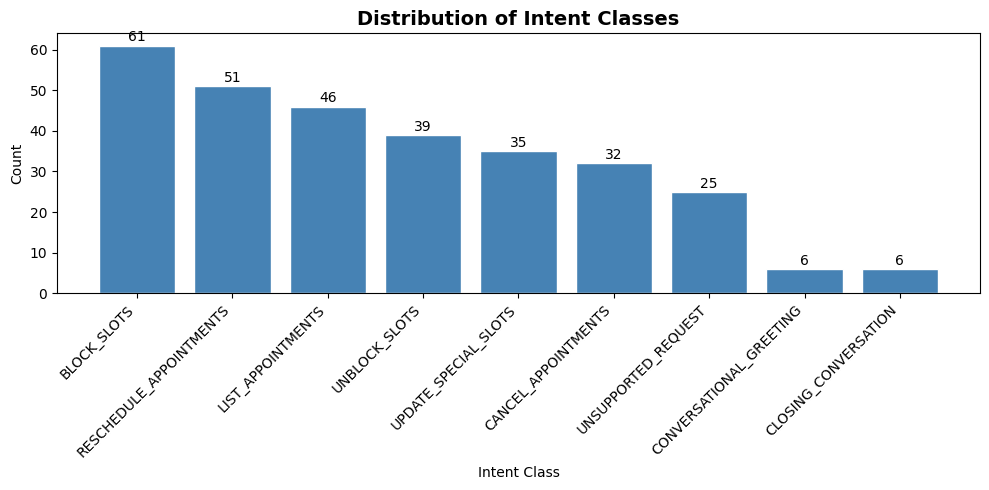

TARGET_INTENT
BLOCK_SLOTS                61
RESCHEDULE_APPOINTMENTS    51
LIST_APPOINTMENTS          46
UNBLOCK_SLOTS              39
UPDATE_SPECIAL_SLOTS       35
CANCEL_APPOINTMENTS        32
UNSUPPORTED_REQUEST        25
CONVERSATIONAL_GREETING     6
CLOSING_CONVERSATION        6


In [ ]:
class_counts = df['TARGET_INTENT'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_counts.index, class_counts.values, color='steelblue', edgecolor='white')

ax.set_title('Distribution of Intent Classes', fontsize=14, fontweight='bold')
ax.set_xlabel('Intent Class')
ax.set_ylabel('Count')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(class_counts.to_string())

---

## Step 3: Set Up the Model Environment

Before we can work with an LLM, we need three things:
1. **A Hugging Face token** — to download the model (some models are gated and require authentication)
2. **A GPU** — LLMs are computationally expensive; we need GPU acceleration
3. **A model to use** — we'll use Meta's Llama 3.2 (1B parameter version)

In [ ]:
# Hugging Face & Base model

### Authenticate with Hugging Face

Llama 3.2 is a **gated model**, meaning you need to:
1. Create a free account at [huggingface.co](https://huggingface.co)
2. Accept the Llama 3.2 license agreement on the model page
3. Generate an access token and store it in Colab's Secrets (key icon in the left sidebar)

In [ ]:
#You'll need the hugging face token to download the base model
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')
print(f"Token loaded: {'✓' if HF_TOKEN else '✗'}")

Token loaded: ✓


### Check GPU Availability

Fine-tuning and running LLMs requires a GPU. In Google Colab, go to **Runtime > Change runtime type** and select a GPU (T4 is free and sufficient for this lab).

In [ ]:
# Check GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Using device: {device}")
if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ Using device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


### Choose the Base Model

We're using **Llama 3.2-1B-Instruct** — a 1-billion parameter model from Meta that has already been instruction-tuned. The "Instruct" variant means it's been trained to follow instructions, which gives us a good starting point.

> **Why 1B?** Larger models (7B, 70B) are more capable but require more memory and time to fine-tune. The 1B model fits comfortably on a free Colab T4 GPU and is perfect for learning.

In [ ]:
# the model we're interested in
MODEL_ID = "meta-llama/Llama-3.2-1B-Instruct"

---

## Step 4: Understanding Tokenizers

### What is a Tokenizer?

LLMs don't understand text directly — they work with **numbers**. A tokenizer converts text into a sequence of **token IDs** (integers) that the model can process.

```
"Hello world" → [15339, 1917] → Model → [output tokens] → "Response text"
```

**Key concepts:**
- **Vocabulary**: The set of all tokens the model knows (Llama 3.2 has ~128,000 tokens)
- **Encoding**: Converting text → token IDs
- **Decoding**: Converting token IDs → text
- **Special tokens**: Tokens like `<|begin_of_text|>` that mark the start/end of sequences
- **Padding**: Making all sequences in a batch the same length (required for efficient GPU processing)

Let's explore how the tokenizer works step by step.

In [ ]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

In [ ]:
print(f"Vocabulary size: {len(tokenizer)}")

Vocabulary size: 128256


#### Encoding and Decoding

**Encoding** converts text into token IDs. **Decoding** converts token IDs back to text. Let's see this in action — notice how the tokenizer breaks words into subword pieces.

In [ ]:
tokenizer.encode("Welcome to the finetuning workshop")

[128000, 14262, 311, 279, 1913, 295, 38302, 26129]

In [ ]:
tokenizer.decode([128000])

'<|begin_of_text|>'

In [ ]:
tokenizer.decode([38302])

'uning'

#### Full Tokenizer Output

When you call the tokenizer directly (not just `.encode()`), it returns a dictionary with:
- **`input_ids`**: The token IDs
- **`attention_mask`**: A mask of 1s and 0s indicating which tokens are real vs. padding

In [ ]:
tokenizer("Short text")

{'input_ids': [128000, 12755, 1495], 'attention_mask': [1, 1, 1]}

In [ ]:
tokenizer('hello')

{'input_ids': [128000, 15339], 'attention_mask': [1, 1]}

In [ ]:
tokenizer.decode([15339])

'hello'

In [ ]:
tokenizer.encode('hello', add_special_tokens=False)

[15339]

#### Why Padding Matters

When processing multiple texts in a **batch**, all sequences must be the same length. The tokenizer adds **padding tokens** to shorter sequences. The **attention mask** tells the model which tokens are real content (1) and which are just padding (0) — so the model ignores padding during computation.

> We set `tokenizer.pad_token = tokenizer.eos_token` earlier because Llama's tokenizer doesn't have a default padding token.

In [ ]:
# Without setting pad_token, this would fail:
texts = [
    "Short text",
    "This is a much longer text example"
]

# Tokenize with padding
encoded = tokenizer(
    texts,
    padding=True,  # Pad to longest sequence in batch
    return_tensors="pt"
)

print(encoded['input_ids'])
# Shape: [2, max_length] - both sequences same length now!
print(encoded['attention_mask'])
# Shows which tokens are real (1) vs padding (0)

tensor([[128000,  12755,   1495, 128009, 128009, 128009, 128009, 128009],
        [128000,   2028,    374,    264,   1790,   5129,   1495,   3187]])
tensor([[1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]])


In [ ]:
tokenizer.decode([128009])

'<|eot_id|>'

---

## Step 5: Load the Base Model

Now we load the actual LLM — all 1 billion parameters! This is the **pre-trained** model before any fine-tuning.

**Key settings:**
- **`torch.float16`** — Uses half-precision floating point to cut memory usage in half
- **`device_map="auto"`** — Automatically places the model on the GPU
- **`.eval()`** — Puts the model in evaluation mode (disables dropout, etc.)

In [ ]:
print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float16,
    device_map="auto",
)
base_model.eval()
print("✅ Base model loaded!")
print(f"   Parameters: {sum(p.numel() for p in base_model.parameters()) / 1e6:.0f}M")

Loading base model...


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

✅ Base model loaded!
   Parameters: 1236M


---

## Step 6: Run Inference with the Base Model

Now let's see how the base model performs on our intent classification task **before any fine-tuning**. This gives us a baseline to compare against later.

### Define the Task

First, we define:
- **INTENTS**: The list of valid intent labels the model should choose from
- **SYSTEM_PROMPT**: Instructions telling the model what to do — classify user messages into exactly one intent

In [ ]:
# inference
INTENTS = [
    "LIST_APPOINTMENTS",
    "CANCEL_APPOINTMENTS",
    "RESCHEDULE_APPOINTMENTS",
    "UNSUPPORTED_REQUEST",
    "BLOCK_SLOTS",
    "UNBLOCK_SLOTS",
    "UPDATE_SPECIAL_SLOTS",
    "CONVERSATIONAL_GREETING",
    "CLOSING_CONVERSATION"
]

SYSTEM_PROMPT = f"""You are an intent classifier for a doctor appointment booking system.
    Classify the user message into exactly one of these following intents:
    {", ".join(INTENTS)}

    Reply with ONLY the EXACT intent label. Nothing else.
    """


### Manual Inference — Step by Step

Let's walk through the inference process manually so you understand what happens under the hood. We'll take a single user message and see how the model processes it.

In [ ]:
user_message = "List appointments for tomorrow"

We construct the full **prompt** by combining the system prompt with the user message. This is what the model actually sees as input.

In [ ]:
prompt = f""" {SYSTEM_PROMPT}

    User: {user_message}

    Intent:"""

In [ ]:
prompt

' You are an intent classifier for a doctor appointment booking system.\n    Classify the user message into exactly one of these following intents:\n    LIST_APPOINTMENTS, CANCEL_APPOINTMENTS, RESCHEDULE_APPOINTMENTS, UNSUPPORTED_REQUEST, BLOCK_SLOTS, UNBLOCK_SLOTS, UPDATE_SPECIAL_SLOTS, CONVERSATIONAL_GREETING, CLOSING_CONVERSATION\n\n    Reply with ONLY the EXACT intent label. Nothing else.\n    \n\n    User: List appointments for tomorrow\n\n    Intent:'

**Tokenize the prompt** — convert our text prompt into token IDs and move them to the GPU where the model lives.

In [ ]:
# tokenize -> prepare inputs
inputs = tokenizer(prompt, return_tensors="pt")
inputs = inputs.to(base_model.device) #moves the input tensors to the same device where the model is located.


In [ ]:
inputs

{'input_ids': tensor([[128000,   1472,    527,    459,   7537,  34465,    369,    264,  10896,
          18101,  22615,   1887,    627,    262,   3308,   1463,    279,   1217,
           1984,   1139,   7041,    832,    315,   1521,   2768,  94615,    512,
            262,  28064,  22661,  22255,  29863,     11,    356,  31099,  22661,
          22255,  29863,     11,  13472,  56322,  22661,  22255,  29863,     11,
          47083,  62240,  14793,     11,  29777,   1117,  75702,     11,   6781,
          41064,   1117,  75702,     11,  23743,  65340,   1117,  75702,     11,
           3501,  73326,  40685,   2712,  57021,   1753,     11,    356,  38658,
           1753,   4405,  73326,   3579,    271,    262,  18321,    449,  27785,
            279,   4154,   6966,   7537,   2440,     13,  12334,    775,    627,
          15152,    262,   2724,     25,   1796,  37256,    369,  16986,    271,
            262,   9005,     25]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 

In [ ]:
# print(inputs)
print("Input shape:", inputs["input_ids"].shape)

Input shape: torch.Size([1, 102])


**Generate the response** — the model predicts the next tokens given our prompt.

- **`max_new_tokens=4`**: We only need a short response (just the intent label)
- **`do_sample=False`**: Use greedy decoding (always pick the most likely next token) for deterministic results
- **`torch.no_grad()`**: Disables gradient computation since we're only doing inference, not training — this saves memory

In [ ]:
# inference
with torch.no_grad():
    outputs = base_model.generate(
        **inputs,
        max_new_tokens=4,     # small since we only need intent
        do_sample=False,
        use_cache=True,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [ ]:
outputs

tensor([[128000,   1472,    527,    459,   7537,  34465,    369,    264,  10896,
          18101,  22615,   1887,    627,    262,   3308,   1463,    279,   1217,
           1984,   1139,   7041,    832,    315,   1521,   2768,  94615,    512,
            262,  28064,  22661,  22255,  29863,     11,    356,  31099,  22661,
          22255,  29863,     11,  13472,  56322,  22661,  22255,  29863,     11,
          47083,  62240,  14793,     11,  29777,   1117,  75702,     11,   6781,
          41064,   1117,  75702,     11,  23743,  65340,   1117,  75702,     11,
           3501,  73326,  40685,   2712,  57021,   1753,     11,    356,  38658,
           1753,   4405,  73326,   3579,    271,    262,  18321,    449,  27785,
            279,   4154,   6966,   7537,   2440,     13,  12334,    775,    627,
          15152,    262,   2724,     25,   1796,  37256,    369,  16986,    271,
            262,   9005,     25,  28064,  22661,  22255,  29863]],
       device='cuda:0')

**Extract only the new tokens** — the model output includes the entire input + the generated tokens. We slice off just the new part and decode it back to text.

In [ ]:
# new tokens
new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
new_tokens

tensor([28064, 22661, 22255, 29863], device='cuda:0')

In [ ]:
decoded = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
decoded

'LIST_APPOINTMENTS'

### A Cleaner Approach: Chat Templates

The manual approach above works, but modern instruction-tuned models expect input in a specific **chat format**. The tokenizer's `apply_chat_template()` method handles this formatting automatically.

The function below wraps our inference pipeline into a reusable helper that:
1. Formats the conversation using the model's expected chat template
2. Tokenizes and sends to GPU
3. Generates a response
4. Decodes and returns only the new tokens

In [ ]:
def run_inference(model, tokenizer, system_prompt, user_message):

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": user_message},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    inputs = tokenizer(prompt, return_tensors="pt")
    inputs = inputs.to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens= 10,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.eos_token_id,
        )

    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    decoded = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    return decoded

Let's test our helper function with the same message. Notice how using the proper chat template may give different (often better) results than our manual prompt construction.

In [ ]:
run_inference(base_model, tokenizer, SYSTEM_PROMPT, user_message)

'LIST_APPOINTMENTS'

---

## Step 7: Prepare Data for Fine-Tuning

Before we can fine-tune the model, we need to prepare our dataset:
1. **Clean the data** — strip whitespace and ensure consistency
2. **Split into train/test** — so we can evaluate on data the model hasn't seen during training

We reload the dataset fresh to ensure a clean starting point.

In [ ]:
df = pd.read_csv('finetuning_preference_dataset.csv')
df.head()

,TEST_ID,USER_INPUT,TARGET_INTENT
0,TEST_001,List my schedule for this afternoon.,LIST_APPOINTMENTS
1,TEST_002,What are my appointments Tuesday morning?,LIST_APPOINTMENTS
2,TEST_003,What's on my calendar this week?,LIST_APPOINTMENTS
3,TEST_004,What is my availability Monday morning?,LIST_APPOINTMENTS
4,TEST_005,View my schedule New Years Eve,LIST_APPOINTMENTS


### Clean the Data

A quick but important step — strip whitespace from our columns to prevent mismatches during evaluation (e.g., `"LIST_APPOINTMENTS"` vs `"LIST_APPOINTMENTS "`).

In [ ]:
# Strip any whitespace from column values
df['USER_INPUT'] = df['USER_INPUT'].astype(str).str.strip()
df['TARGET_INTENT'] = df['TARGET_INTENT'].astype(str).str.strip()


### Train/Test Split

We split the data **80/20** using **stratified sampling**, which ensures each intent class is proportionally represented in both the training and test sets. This prevents the model from being evaluated on intents it barely saw during training.

- **`random_state=42`** — Makes the split reproducible
- **`stratify=df['TARGET_INTENT']`** — Maintains class proportions

In [ ]:
# ─────────────────────────────────────────────────────────────
# Stratified 80/20 Train/Test Split
# ─────────────────────────────────────────────────────────────

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['TARGET_INTENT'],
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Stratified Split Complete")
print(f"   Training set:  {len(train_df)} examples ({len(train_df)/len(df):.0%})")
print(f"   Test set:      {len(test_df)} examples ({len(test_df)/len(df):.0%})")
print()

# Verify stratification
print("Per-class split verification:")
print(f"  {'Intent':<30} {'Train':>6} {'Test':>6} {'Total':>6}")
print("  " + "-" * 52)
for intent in sorted(df['TARGET_INTENT'].unique()):
    n_train = (train_df['TARGET_INTENT'] == intent).sum()
    n_test = (test_df['TARGET_INTENT'] == intent).sum()
    n_total = n_train + n_test
    print(f"  {intent:<30} {n_train:>6} {n_test:>6} {n_total:>6}")

Stratified Split Complete
   Training set:  240 examples (80%)
   Test set:      61 examples (20%)

Per-class split verification:
  Intent                          Train   Test  Total
  ----------------------------------------------------
  BLOCK_SLOTS                        48     13     61
  CANCEL_APPOINTMENTS                25      7     32
  CLOSING_CONVERSATION                5      1      6
  CONVERSATIONAL_GREETING             5      1      6
  LIST_APPOINTMENTS                  37      9     46
  RESCHEDULE_APPOINTMENTS            41     10     51
  UNBLOCK_SLOTS                      31      8     39
  UNSUPPORTED_REQUEST                20      5     25
  UPDATE_SPECIAL_SLOTS               28      7     35


---

## Step 8: Establish a Baseline

Before fine-tuning, we evaluate the **base model** (no fine-tuning) on both the training and test sets. This gives us a baseline to measure improvement against.

**Evaluation metrics:**
- **Accuracy** — What percentage of predictions are correct?
- **F1 Score (weighted)** — Balances precision and recall, weighted by class frequency. More informative than accuracy when classes are imbalanced.
- **F1 Score (macro)** — Unweighted average across all classes — treats rare classes equally.

> This step takes a few minutes since we're running inference on every example in the dataset.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model(model, tokenizer, system_prompt, eval_df, split_name="eval"):
    predictions = []
    targets = []

    for idx, row in eval_df.iterrows():
        pred = run_inference(model, tokenizer, system_prompt, row['USER_INPUT'])
        predictions.append(pred.lower().strip())
        targets.append(row['TARGET_INTENT'].lower().strip())

        if (idx + 1) % 50 == 0:
            print(f"  Processed {idx + 1}/{len(eval_df)} examples...")

    acc = accuracy_score(targets, predictions)
    f1_macro = f1_score(targets, predictions, average='macro', zero_division=0)
    f1_weighted = f1_score(targets, predictions, average='weighted', zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {split_name} Results")
    print(f"{'='*50}")
    print(f"  Accuracy:           {acc:.4f} ({acc*100:.1f}%)")
    print(f"  F1 (macro):         {f1_macro:.4f}")
    print(f"  F1 (weighted):      {f1_weighted:.4f}")
    print(f"{'='*50}\n")

    return {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted,
            "predictions": predictions, "targets": targets}

print("Evaluating baseline on TRAINING set...")
train_results = evaluate_model(base_model, tokenizer, SYSTEM_PROMPT, train_df, "Baseline - Training")

print("Evaluating baseline on TEST set...")
test_results = evaluate_model(base_model, tokenizer, SYSTEM_PROMPT, test_df, "Baseline - Test")

Evaluating baseline on TRAINING set...
  Processed 50/240 examples...
  Processed 100/240 examples...
  Processed 150/240 examples...
  Processed 200/240 examples...

  Baseline - Training Results
  Accuracy:           0.3667 (36.7%)
  F1 (macro):         0.1403
  F1 (weighted):      0.3199

Evaluating baseline on TEST set...
  Processed 50/61 examples...

  Baseline - Test Results
  Accuracy:           0.4426 (44.3%)
  F1 (macro):         0.2394
  F1 (weighted):      0.3619



In [ ]:
# Class-wise Precision & Recall

# intents_lower = [intent.lower() for intent in INTENTS]

# print("\nClass-wise Report for Baseline Model (Training Set):")
# print(classification_report(train_results['targets'], train_results['predictions'], labels=intents_lower, zero_division=0))

---

## Step 9: Fine-Tuning

Now for the main event! We'll fine-tune the base model to improve its intent classification performance. Instead of training all 1 billion parameters (which would require massive compute), we'll use **LoRA** — a technique that trains only a tiny fraction of the parameters while achieving comparable results.

## SFT with LoRA

### What is LoRA?

**LoRA (Low-Rank Adaptation)** is a parameter-efficient fine-tuning technique. Instead of updating all 1 billion weights in the model, we **freeze the original weights** and add small trainable "adapter" matrices to specific layers.

```
FULL FINE-TUNING          LoRA FINE-TUNING
─────────────────         ──────────────────────────────────
Update ALL weights        Original weights W  ← FROZEN ✓
~1B parameters to train   Add small matrices: W + ΔW = W + A×B
Requires huge memory      Only A and B are trained
Risk of catastrophic      ~0.5% of parameters to train
forgetting                Fast, memory-efficient ✓
```

**LoRA hyperparameters:**
- `r` (rank): Size of the adapter matrices. Higher = more capacity but more parameters
- `lora_alpha`: Scaling factor for the LoRA updates
- `target_modules`: Which weight matrices to apply LoRA to (query, key, value projections etc.)

In [ ]:
# ─────────────────────────────────────────────────────────────
# Configure LoRA adapters
# ─────────────────────────────────────────────────────────────

lora_config = LoraConfig(
    r=16,                          # Rank of adapter matrices
    lora_alpha=32,                 # Scaling factor (typically 2 * r)
    target_modules=[               # Apply LoRA to attention + MLP layers
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)


### Load a Fresh Copy of the Base Model

We load a **second copy** of the base model specifically for fine-tuning. This way, we keep our original `base_model` intact for comparison later.

> **`use_cache = False`** is set because caching is incompatible with gradient checkpointing used during training.

In [ ]:
# Reload base model fresh before applying LoRA
# (so our ft_model is independent of the base_model we're keeping for comparison)
print("Loading fresh copy of base model for fine-tuning...")
ft_model_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)
ft_model_base.config.use_cache = False

Loading fresh copy of base model for fine-tuning...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

### Apply LoRA to the Model

Now we wrap our base model with the LoRA adapters. Watch the trainable parameter count — it should be a tiny fraction (~0.5%) of the total parameters. This is the magic of LoRA: we get fine-tuning results while training far fewer parameters.

In [ ]:
ft_model_peft = get_peft_model(ft_model_base, lora_config)

# Show trainable parameter count
total_params = sum(p.numel() for p in ft_model_peft.parameters())
trainable_params = sum(p.numel() for p in ft_model_peft.parameters() if p.requires_grad)
print(f"\n✅ LoRA applied!")
print(f"   Total parameters:     {total_params:>12,}")
print(f"   Trainable parameters: {trainable_params:>12,} ({100 * trainable_params / total_params:.2f}%)")
print(f"   Frozen parameters:    {total_params - trainable_params:>12,}")


✅ LoRA applied!
   Total parameters:     1,247,086,592
   Trainable parameters:   11,272,192 (0.90%)
   Frozen parameters:    1,235,814,400


### Format Training Data

The SFT trainer expects each training example as a **complete conversation string** in the model's chat format. We format each example as a conversation with:
- A **system message** (the classification instructions)
- A **user message** (the input text)
- An **assistant message** (the correct intent label)

The tokenizer's `apply_chat_template()` converts this into the exact format the model was pre-trained with.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Format data for SFT training
# Each example becomes a full conversation string
# ─────────────────────────────────────────────────────────────

def format_training_example(user_message, label):
    """Format a training example as a chat conversation."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_message},
        {"role": "assistant", "content": label},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False)


formatted_examples = [
    {"text": format_training_example(row['USER_INPUT'], row['TARGET_INTENT'])}
    for _, row in train_df.iterrows()
]

train_dataset = Dataset.from_list(formatted_examples)

print("✅ Dataset formatted for SFT")
print(f"   Total training examples: {len(train_dataset)}")

✅ Dataset formatted for SFT
   Total training examples: 240


Let's look at what a formatted training example looks like. Notice the special tokens (`<|begin_of_text|>`, `<|start_header_id|>`, etc.) — these are the chat template markers that Llama uses.

In [ ]:
# Sample formatted example
print(formatted_examples[0]["text"])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 28 Mar 2026

You are an intent classifier for a doctor appointment booking system.
    Classify the user message into exactly one of these following intents:
    LIST_APPOINTMENTS, CANCEL_APPOINTMENTS, RESCHEDULE_APPOINTMENTS, UNSUPPORTED_REQUEST, BLOCK_SLOTS, UNBLOCK_SLOTS, UPDATE_SPECIAL_SLOTS, CONVERSATIONAL_GREETING, CLOSING_CONVERSATION

    Reply with ONLY the EXACT intent label. Nothing else.<|eot_id|><|start_header_id|>user<|end_header_id|>

I'm free on Friday<|eot_id|><|start_header_id|>assistant<|end_header_id|>

UNBLOCK_SLOTS<|eot_id|>


### Configure and Run Training

Here's where we set up the training hyperparameters. Key settings explained:

| Parameter | Value | What it Does |
|-----------|-------|-------------|
| `num_train_epochs` | 5 | Number of full passes through the training data |
| `per_device_train_batch_size` | 4 | Examples processed per GPU at once |
| `gradient_accumulation_steps` | 2 | Accumulate gradients over 2 batches before updating (effective batch size = 8) |
| `learning_rate` | 2e-4 | How much to adjust weights per step (standard for LoRA) |
| `lr_scheduler_type` | cosine | Gradually decrease learning rate following a cosine curve |
| `warmup_steps` | 10 | Slowly ramp up learning rate at the start to stabilize training |
| `fp16` | True | Use half-precision to save memory |
| `optim` | paged_adamw_8bit | Memory-efficient optimizer |

In [ ]:
# ─────────────────────────────────────────────────────────────
# Training configuration & run
# ─────────────────────────────────────────────────────────────

sft_config = SFTConfig(
    output_dir="./sft-intent-classifier",
    num_train_epochs=5,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,      # Effective batch size = 8
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=10,                    # replaced warmup_ratio
    logging_steps=10,
    save_strategy="epoch",
    fp16=True,
    optim="paged_adamw_8bit",
    report_to="none",
    dataset_text_field="text",
)


trainer = SFTTrainer(
    model=ft_model_peft,
    args=sft_config,
    train_dataset=train_dataset,
    processing_class=tokenizer,
)

print("🚀 Starting fine-tuning...")
print(f"   Epochs: {sft_config.num_train_epochs}")
print(f"   Effective batch size: {sft_config.per_device_train_batch_size * sft_config.gradient_accumulation_steps}")
print(f"   Learning rate: {sft_config.learning_rate}")
print(f"   Training examples: {len(train_dataset)}")
print()

train_result = trainer.train()

#execution time ~2mins

Adding EOS to train dataset:   0%|          | 0/240 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/240 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/240 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


🚀 Starting fine-tuning...
   Epochs: 5
   Effective batch size: 8
   Learning rate: 0.0002
   Training examples: 240



Step,Training Loss
10,3.130606
20,0.708413
30,0.393717
40,0.288589
50,0.200931
60,0.177295
70,0.153697
80,0.150604
90,0.141289
100,0.118108


### Visualize Training Progress

The **training loss** measures how well the model fits the training data. We expect it to decrease over time — a decreasing loss means the model is learning to predict the correct intent labels.

- A **steep initial drop** means the model is quickly learning the task
- A **plateau** means the model has converged
- If loss **goes back up**, the model may be overfitting

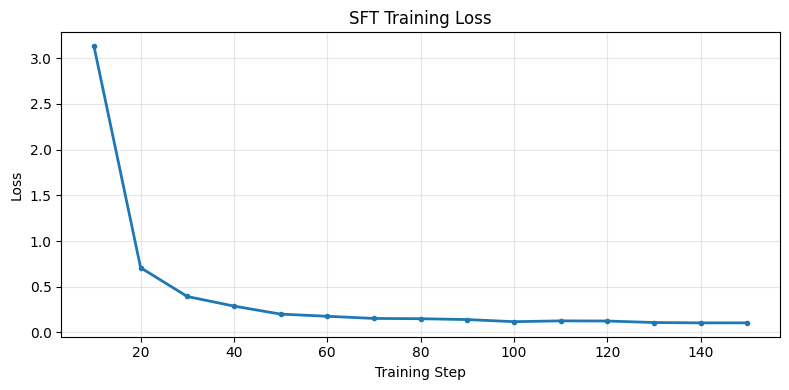

In [ ]:
# Plot training loss
loss_history = [x["loss"] for x in trainer.state.log_history if "loss" in x]
steps = [x["step"] for x in trainer.state.log_history if "loss" in x]

plt.figure(figsize=(8,4))
plt.plot(steps, loss_history, linewidth=2, marker="o", markersize=3)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("SFT Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Step 10: Test the Fine-Tuned Model

Training is done! Let's see how the fine-tuned model performs. First, we switch the model to **evaluation mode** (`.eval()`), which disables dropout and other training-specific behaviors.

Then we'll test it with a few example messages to see if it correctly classifies intents.

In [ ]:
ft_model_peft.eval() # An important step -> switches the model to evaluation mode.

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 2048)
        (layers): ModuleList(
          (0-15): 16 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear

In [ ]:
# Now let's test the finetuned model!
# user_message = "List my schedule for this afternoon."
# user_message = "Cancel my appointments tomorrow afternoon."
user_message = "Block my calendar tomorrow."

In [ ]:
run_inference(ft_model_peft, tokenizer, SYSTEM_PROMPT, user_message)

'BLOCK_SLOTS'

---

## Step 11: Full Evaluation — Base vs. Fine-Tuned

Now for the moment of truth — let's systematically compare the base model and fine-tuned model on both the training and test sets.

**What to look for:**
- **Training set performance** tells us how well the model learned the training data
- **Test set performance** tells us how well the model **generalizes** to unseen data
- A large gap between train and test performance suggests **overfitting**

### Base Model Results (Before Fine-Tuning)

Let's see how the base model performed. Remember, this model was never trained on our specific task — it's relying entirely on its general knowledge from pre-training.

In [ ]:
# Base_train_results :

print(train_results['accuracy'])
print(train_results['f1_weighted'])
print(train_results['f1_weighted'])



0.36666666666666664
0.31991942694363007
0.31991942694363007


In [ ]:
# Base_test_results :

print(test_results['accuracy'])
print(test_results['f1_weighted'])
print(test_results['f1_weighted'])

0.4426229508196721
0.36185153644170037
0.36185153644170037


### Fine-Tuned Model Results

Now let's evaluate our fine-tuned model on the same data. We expect to see a significant improvement.

In [ ]:
# Fine tuned model

In [ ]:
ft_train_results = evaluate_model(ft_model_peft, tokenizer, SYSTEM_PROMPT, train_df, "Fine - Train")

  Processed 50/240 examples...
  Processed 100/240 examples...
  Processed 150/240 examples...
  Processed 200/240 examples...

  Fine - Train Results
  Accuracy:           0.9458 (94.6%)
  F1 (macro):         0.9493
  F1 (weighted):      0.9457



In [ ]:
print(ft_train_results['accuracy'])
print(ft_train_results['f1_weighted'])
print(ft_train_results['f1_weighted'])

0.9458333333333333
0.9456857590839697
0.9456857590839697


In [ ]:
ft_test_results = evaluate_model(ft_model_peft, tokenizer, SYSTEM_PROMPT, test_df, "Fine - Test")

  Processed 50/61 examples...

  Fine - Test Results
  Accuracy:           0.8361 (83.6%)
  F1 (macro):         0.8311
  F1 (weighted):      0.8246



In [ ]:
print(ft_test_results['accuracy'])
print(ft_test_results['f1_weighted'])
print(ft_test_results['f1_weighted'])

0.8360655737704918
0.824647523662902
0.824647523662902


### Visualize the Results

Finally, let's create a side-by-side visual comparison:

1. **Accuracy bar chart** — Overall accuracy comparison
2. **Confusion matrices** — Show exactly where each model gets confused. Diagonal = correct predictions. Off-diagonal = errors.

> A **confusion matrix** is one of the most useful tools for understanding classification performance. It shows you not just *how often* the model is wrong, but *how* it's wrong — which classes it confuses with each other.

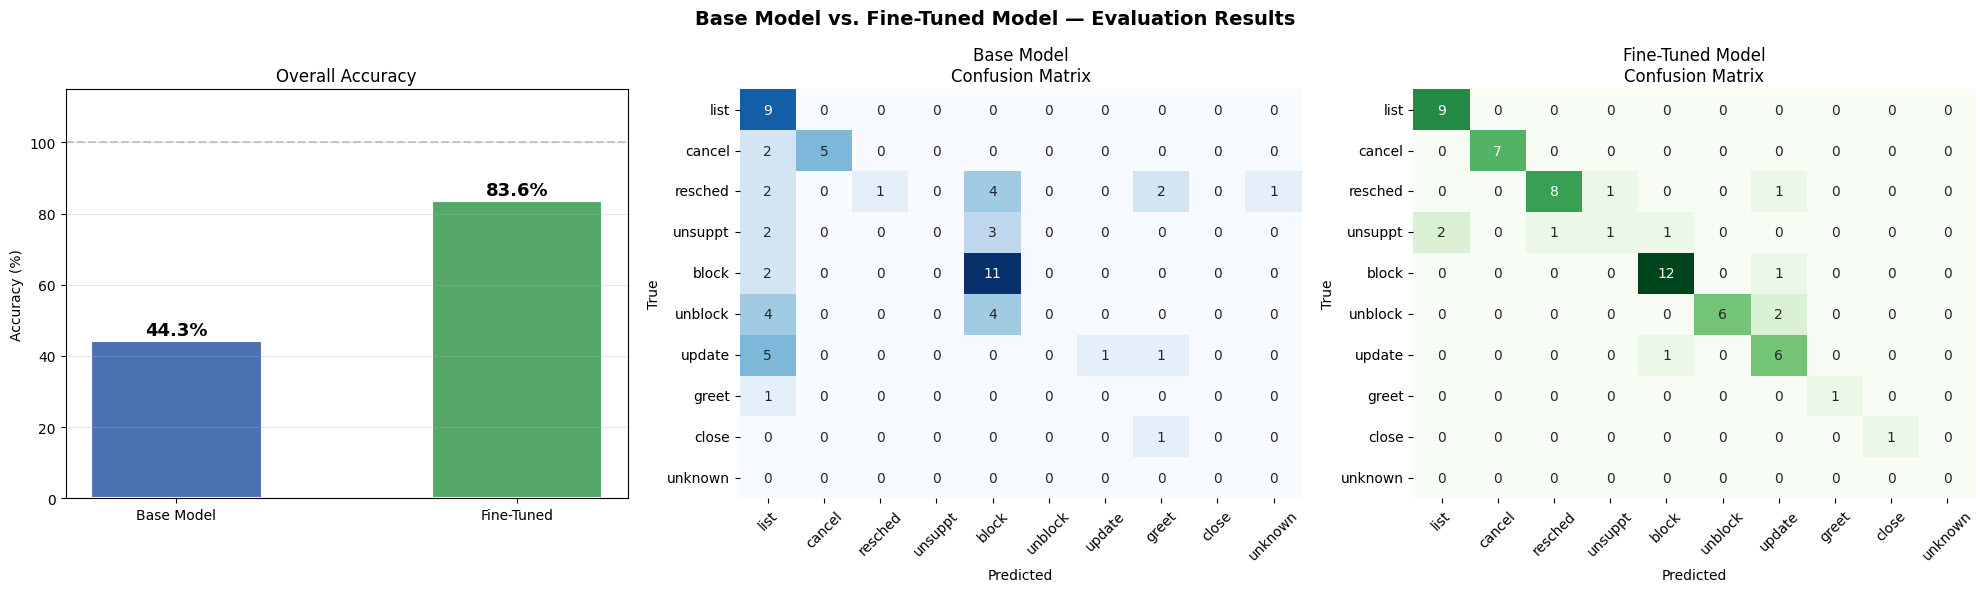


Fine-Tuned Model — Per-Class Report:
                         precision    recall  f1-score   support

      list_appointments       0.82      1.00      0.90         9
    cancel_appointments       1.00      1.00      1.00         7
reschedule_appointments       0.89      0.80      0.84        10
    unsupported_request       0.50      0.20      0.29         5
            block_slots       0.86      0.92      0.89        13
          unblock_slots       1.00      0.75      0.86         8
   update_special_slots       0.60      0.86      0.71         7
conversational_greeting       1.00      1.00      1.00         1
   closing_conversation       1.00      1.00      1.00         1

               accuracy                           0.84        61
              macro avg       0.85      0.84      0.83        61
           weighted avg       0.84      0.84      0.82        61


Base Model — Per-Class Report:
                         precision    recall  f1-score   support

      list_appoi

In [ ]:
import seaborn as sns

# ─────────────────────────────────────────────────────────────
# Visualize evaluation results
# ─────────────────────────────────────────────────────────────

# Extract values from the result dicts
base_acc = test_results['accuracy']
ft_acc = ft_test_results['accuracy']
true_labels = test_results['targets']       # lowercased
base_preds = test_results['predictions']    # lowercased
ft_preds = ft_test_results['predictions']   # lowercased

# Lowercase INTENTS to match evaluate_model output
intents_lower = [i.lower() for i in INTENTS]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Base Model vs. Fine-Tuned Model — Evaluation Results", fontsize=14, fontweight="bold")

# ── Plot 1: Accuracy bar chart ──
ax = axes[0]
bars = ax.bar(
    ["Base Model", "Fine-Tuned"],
    [base_acc * 100, ft_acc * 100],
    color=["#4C72B0", "#55A868"],
    width=0.5,
    edgecolor="white",
    linewidth=1.5,
)
for bar, val in zip(bars, [base_acc, ft_acc]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{val:.1%}", ha="center", fontweight="bold", fontsize=13)
ax.set_ylim(0, 115)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Overall Accuracy")
ax.axhline(y=100, color="gray", linestyle="--", alpha=0.4)
ax.grid(axis="y", alpha=0.3)

# ── Plot 2: Confusion matrix — Base model ──
ax = axes[1]
short_labels = ["list", "cancel", "resched", "unsuppt", "block",
                "unblock", "update", "greet", "close"]
label_map = {intent: short for intent, short in zip(intents_lower, short_labels)}
true_short = [label_map.get(l, "unknown") for l in true_labels]
base_short = [label_map.get(l, "unknown") for l in base_preds]
ft_short   = [label_map.get(l, "unknown") for l in ft_preds]

# Include "unknown" in labels if any model produced predictions outside INTENTS
display_labels = short_labels.copy()
if "unknown" in set(base_short) or "unknown" in set(ft_short):
    display_labels.append("unknown")

base_cm = confusion_matrix(true_short, base_short, labels=display_labels)
sns.heatmap(base_cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=display_labels, yticklabels=display_labels, cbar=False)
ax.set_title("Base Model\nConfusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

# ── Plot 3: Confusion matrix — Fine-tuned model ──
ax = axes[2]
ft_cm = confusion_matrix(true_short, ft_short, labels=display_labels)
sns.heatmap(ft_cm, annot=True, fmt="d", cmap="Greens", ax=ax,
            xticklabels=display_labels, yticklabels=display_labels, cbar=False)
ax.set_title("Fine-Tuned Model\nConfusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

# Per-class reports
print("\nFine-Tuned Model — Per-Class Report:")
print(classification_report(true_labels, ft_preds, labels=intents_lower, zero_division=0))
print("\nBase Model — Per-Class Report:")
print(classification_report(true_labels, base_preds, labels=intents_lower, zero_division=0))

---

## Summary & Key Takeaways

Congratulations! You've successfully fine-tuned an LLM for intent classification. Here's what we covered:

### The Fine-Tuning Pipeline
1. **Explored the data** — Understood our intent classes and their distribution
2. **Loaded a pre-trained model** — Llama 3.2-1B-Instruct as our starting point
3. **Established a baseline** — Measured the base model's performance before fine-tuning
4. **Applied LoRA** — Added tiny trainable adapter matrices (~0.5% of parameters)
5. **Trained with SFT** — Showed the model correct input-output pairs
6. **Evaluated** — Compared base vs. fine-tuned model performance

### Key Concepts
- **Tokenization** is how text becomes numbers that models can process
- **LoRA** makes fine-tuning accessible by training only a small fraction of parameters
- **SFT (Supervised Fine-Tuning)** teaches the model by showing it correct examples
- **Evaluation metrics** (accuracy, F1, confusion matrix) help us understand model performance beyond a single number

---

## Insights from the Results

### Why Did Fine-Tuning Work So Well?

1. **The base model already "knows" language** — Llama 3.2 was pre-trained on trillions of tokens, so it already understands English grammar, semantics, and even domain concepts like "appointments" and "calendar." Fine-tuning didn't teach it language — it taught it the *specific output format* we need.

2. **The task is well-scoped** — Intent classification is a constrained problem with a fixed set of 9 labels. The model doesn't need to generate creative text — it just needs to pick the right category. This is an ideal use case for SFT.

3. **LoRA is surprisingly effective** — We only trained ~0.5% of the model's parameters, yet achieved dramatic improvements. This works because LoRA targets the attention and MLP layers that control *how the model reasons about and responds to input*, without disturbing the general language knowledge stored in the frozen weights.

### What the Confusion Matrix Tells Us

- **Base model confusion patterns**: Look at where the base model made mistakes. It likely struggled with semantically similar intents (e.g., confusing `BLOCK_SLOTS` with `CANCEL_APPOINTMENTS`, or `UNBLOCK_SLOTS` with `LIST_APPOINTMENTS`). It may also have produced outputs that don't match any of our intent labels — these show up in the "unknown" column.

- **Fine-tuned model improvements**: After fine-tuning, the confusion matrix should show a strong diagonal (correct predictions) with very few off-diagonal errors. The model learned the exact label vocabulary and the subtle differences between similar intents.

### Practical Takeaways for Your Own Projects

| Insight | Why It Matters |
|---------|---------------|
| **A small, high-quality dataset goes a long way** | We fine-tuned with a relatively small dataset. For classification tasks, even a few hundred well-labeled examples per class can yield strong results. |
| **Always establish a baseline first** | Without measuring the base model, you can't prove fine-tuning actually helped. The baseline also reveals which classes are already easy vs. hard for the model. |
| **LoRA makes fine-tuning accessible** | You don't need massive GPU clusters. LoRA lets you fine-tune billion-parameter models on a single consumer GPU (like the free T4 in Colab). |
| **Evaluation > Accuracy alone** | Accuracy can be misleading with imbalanced classes. The F1 score and confusion matrix give you a much clearer picture of where the model succeeds and fails. |
| **The chat template matters** | Using the model's expected chat format (via `apply_chat_template`) produces better results than ad-hoc prompt construction. Always match the format the model was pre-trained with. |

### When to Fine-Tune vs. When to Prompt

| Approach | Best For |
|----------|----------|
| **Prompt Engineering** | Quick experiments, general tasks, when you don't have labeled data |
| **Fine-Tuning (SFT + LoRA)** | Domain-specific tasks, strict output formats, when you have labeled examples and need consistent, reliable performance |
| **Full Fine-Tuning** | Maximum performance when you have large datasets and significant compute budget |

> **Rule of thumb**: Start with prompting. If the model doesn't reliably produce the output format or accuracy you need, fine-tuning with even a small labeled dataset can close the gap dramatically — as we saw today.

